In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

df = pd.read_csv("/content/healthcare-dataset-stroke-data (2).csv")
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Data Cleaning

In [ ]:
print("Missing BMI values:", df["bmi"].isna().sum())
print("Class balance:\n", df["stroke"].value_counts())

# drop the single 'Other' gender row (too rare to model), impute BMI with median, drop id
df = df[df["gender"] != "Other"].copy()
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
df = df.drop(columns=["id"])
df.info()

Missing BMI values: 201
Class balance:
 stroke
0    4861
1     249
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB


Exploratory Data Analysis

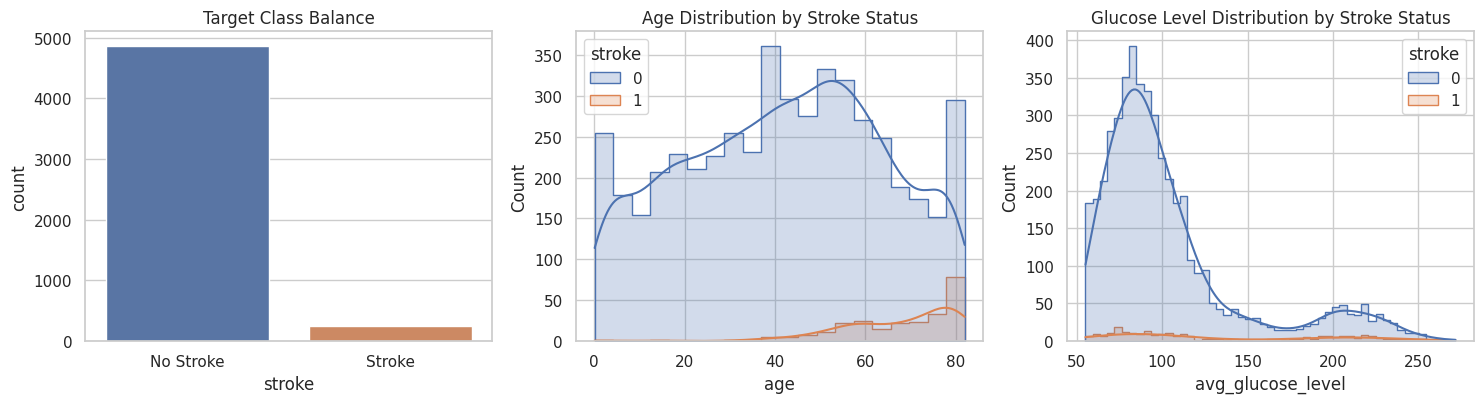

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.countplot(data=df, x="stroke", ax=axes[0], hue="stroke", legend=False, palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Target Class Balance")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["No Stroke", "Stroke"])

sns.histplot(data=df, x="age", hue="stroke", kde=True, ax=axes[1], palette=["#4C72B0", "#DD8452"], element="step")
axes[1].set_title("Age Distribution by Stroke Status")

sns.histplot(data=df, x="avg_glucose_level", hue="stroke", kde=True, ax=axes[2], palette=["#4C72B0", "#DD8452"], element="step")
axes[2].set_title("Glucose Level Distribution by Stroke Status")
plt.tight_layout()
plt.show()

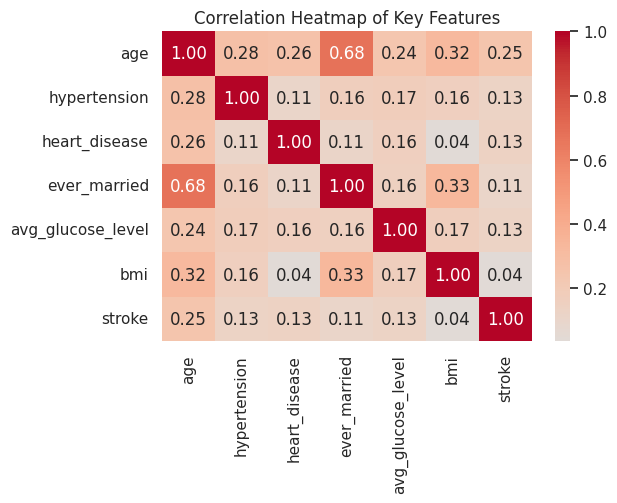

In [ ]:
corr_df = df.copy()
corr_df["ever_married"] = corr_df["ever_married"].map({"Yes": 1, "No": 0})
num_cols = ["age", "hypertension", "heart_disease", "ever_married", "avg_glucose_level", "bmi", "stroke"]
plt.figure(figsize=(6.5, 5.2))
sns.heatmap(corr_df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Features")
plt.tight_layout()
plt.show()

Hypothesis Testing

In [ ]:
age_stroke = df[df.stroke == 1]["age"]
age_no = df[df.stroke == 0]["age"]
t_age, p_age = stats.ttest_ind(age_stroke, age_no, equal_var=False)
print(f"H1 — Age t-test: t = {t_age:.3f}, p = {p_age:.3e}")
print(f"   Mean age (stroke) = {age_stroke.mean():.1f}, Mean age (no stroke) = {age_no.mean():.1f}")

ct = pd.crosstab(df["hypertension"], df["stroke"])
chi2, p_chi, dof, exp = stats.chi2_contingency(ct)
print(f"\nH2 — Hypertension chi-square: chi2 = {chi2:.3f}, p = {p_chi:.3e}")

glu_stroke = df[df.stroke == 1]["avg_glucose_level"]
glu_no = df[df.stroke == 0]["avg_glucose_level"]
t_glu, p_glu = stats.ttest_ind(glu_stroke, glu_no, equal_var=False)
print(f"\nH3 — Glucose t-test: t = {t_glu:.3f}, p = {p_glu:.3e}")
print(f"   Mean glucose (stroke) = {glu_stroke.mean():.1f}, Mean glucose (no stroke) = {glu_no.mean():.1f}")

print("\nAll three null hypotheses are rejected at alpha = 0.05 — age, hypertension, and glucose")
print("level are all statistically significant predictors of stroke.")

H1 — Age t-test: t = 29.682, p = 2.176e-95
   Mean age (stroke) = 67.7, Mean age (no stroke) = 42.0

H2 — Hypertension chi-square: chi2 = 81.573, p = 1.689e-19

H3 — Glucose t-test: t = 6.984, p = 2.373e-11
   Mean glucose (stroke) = 132.5, Mean glucose (no stroke) = 104.8

All three null hypotheses are rejected at alpha = 0.05 — age, hypertension, and glucose
level are all statistically significant predictors of stroke.


Outlier Removal (IQR Method)

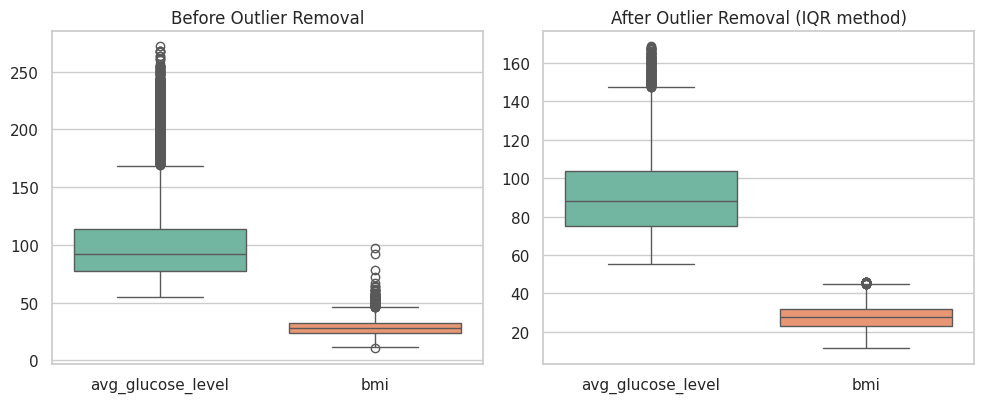

Rows before: 5109  |  Rows after: 4390  |  Removed: 719


In [ ]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
sns.boxplot(data=df[["avg_glucose_level", "bmi"]], ax=axes[0], palette="Set2")
axes[0].set_title("Before Outlier Removal")

before_n = len(df)
mask = pd.Series(True, index=df.index)
for col in ["avg_glucose_level", "bmi"]:
    lo, hi = iqr_bounds(df[col])
    mask &= df[col].between(lo, hi)
df_clean = df[mask].copy()
after_n = len(df_clean)

sns.boxplot(data=df_clean[["avg_glucose_level", "bmi"]], ax=axes[1], palette="Set2")
axes[1].set_title("After Outlier Removal (IQR method)")
plt.tight_layout()
plt.show()

print(f"Rows before: {before_n}  |  Rows after: {after_n}  |  Removed: {before_n - after_n}")

Preprocessing Methodology and Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE

target="stroke"
X,y=df_clean.drop(columns=target),df_clean[target]

cat=["gender","ever_married","work_type","Residence_type","smoking_status"]
num=["age","hypertension","heart_disease","avg_glucose_level","bmi"]

pre=ColumnTransformer([("num",StandardScaler(),num),
         ("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),cat)])
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
Xtr,Xte=pre.fit_transform(Xtr),pre.transform(Xte)

before=Xtr.shape[0]
Xtr,ytr=SMOTE(random_state=42).fit_resample(Xtr,ytr)

print("Train rows before SMOTE:",before)
print("Train rows after SMOTE :",Xtr.shape[0])
print("Test rows (untouched)  :",Xte.shape[0])

models={
"Logistic Regression":LogisticRegression(max_iter=2000,random_state=42),
"K-Nearest Neighbors":KNeighborsClassifier(n_neighbors=7),
"Decision Tree":DecisionTreeClassifier(max_depth=6,min_samples_leaf=20,random_state=42),
"SVM (RBF Kernel)":SVC(kernel="rbf",C=1,gamma="scale",probability=True,random_state=42)}

metrics_table=[]; cms={}; roc_data={}; fitted={}

for name,m in models.items():
    m.fit(Xtr,ytr); fitted[name]=m
    p=m.predict(Xte); pr=m.predict_proba(Xte)[:,1]
    tn,fp,fn,tp=confusion_matrix(yte,p).ravel()
    acc=accuracy_score(yte,p); pre_=precision_score(yte,p,zero_division=0)
    rec=recall_score(yte,p,zero_division=0); f1=f1_score(yte,p,zero_division=0)
    auc=roc_auc_score(yte,pr)
    cms[name]=confusion_matrix(yte,p)
    fpr,tpr,_=roc_curve(yte,pr); roc_data[name]=(fpr,tpr,auc)
    metrics_table.append({"Model":name,"TP":tp,"TN":tn,"FP":fp,"FN":fn,
        "Accuracy":round(acc,4),"Precision":round(pre_,4),
        "Recall":round(rec,4),"F1":round(f1,4),"ROC-AUC":round(auc,4)})

results_df=pd.DataFrame(metrics_table)
results_df

Train rows before SMOTE: 3512
Train rows after SMOTE : 6760
Test rows (untouched)  : 878


,Model,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,21,632,213,12,0.7437,0.0897,0.6364,0.1573,0.7836
1,K-Nearest Neighbors,13,692,153,20,0.8030,0.0783,0.3939,0.1307,0.6765
2,Decision Tree,19,672,173,14,0.7870,0.0990,0.5758,0.1689,0.7596
3,SVM (RBF Kernel),17,677,168,16,0.7904,0.0919,0.5152,0.1560,0.7488


Comparison of TP,TN,FN,FP After Removing Outliers

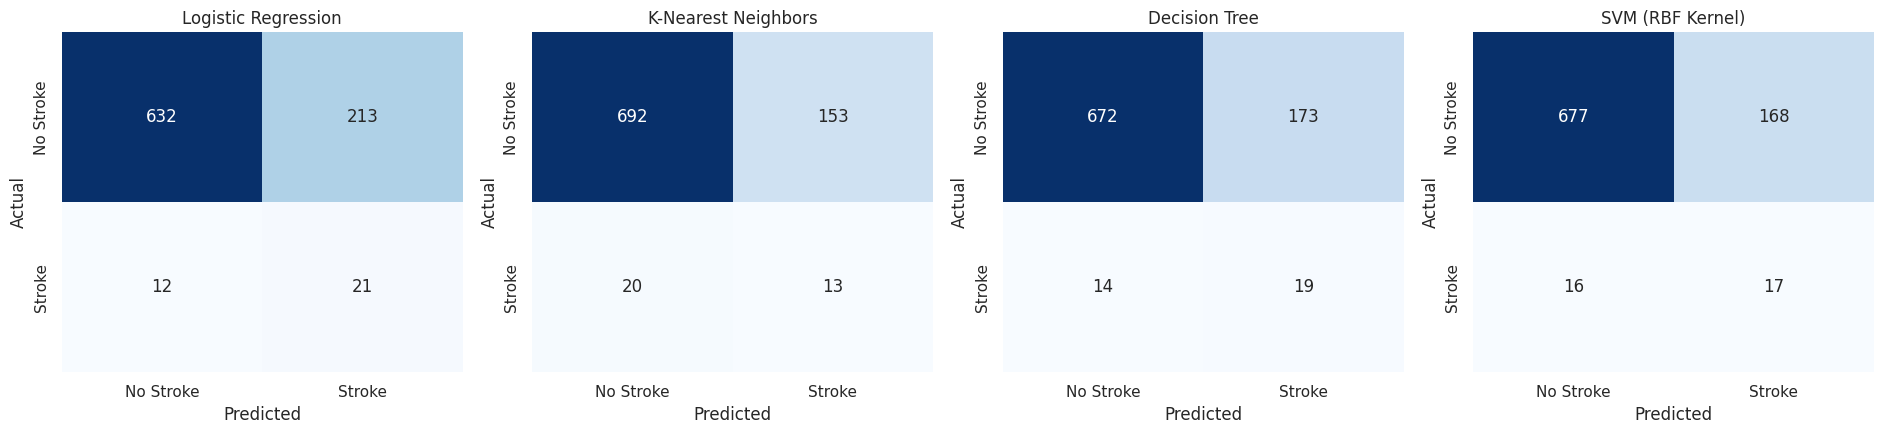

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

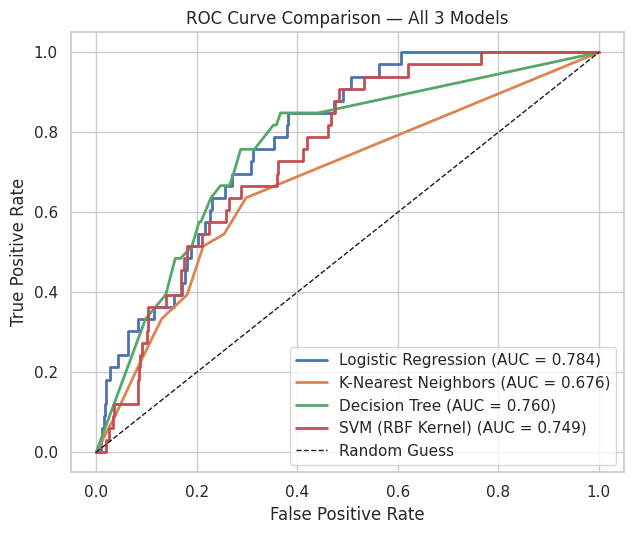

In [ ]:
plt.figure(figsize=(6.5, 5.5))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All 3 Models")
plt.legend()
plt.tight_layout()
plt.show()

  Identification Of Best Model

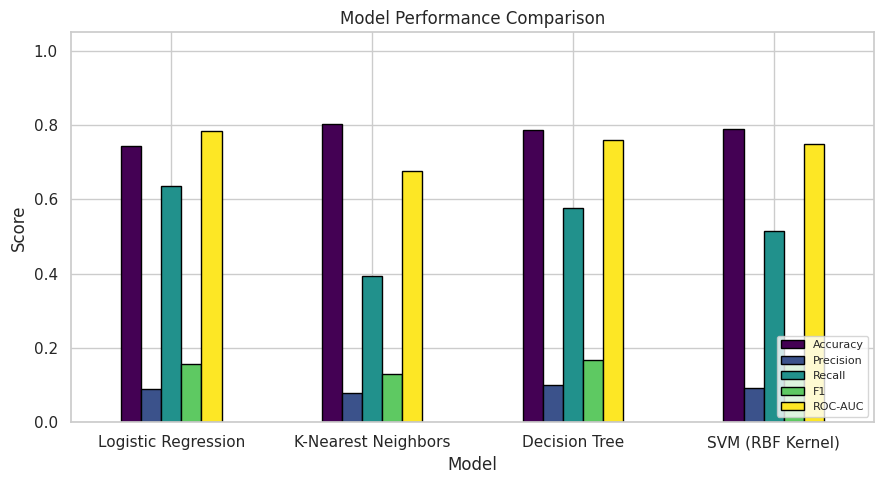

Best model by ROC-AUC: Logistic Regression  (ROC-AUC = 0.7836)

In a medical screening context, Recall matters most — a missed stroke case (false negative)
is far costlier than a false alarm, so the model with the strongest recall/precision balance
and highest ROC-AUC is preferred over the model with the highest raw accuracy.


In [ ]:
mt_plot = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
mt_plot.plot(kind="bar", figsize=(9, 5), colormap="viridis", edgecolor="black")
plt.title("Model Performance Comparison")
plt.ylabel("Score"); plt.xticks(rotation=0); plt.ylim(0, 1.05)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["ROC-AUC"].idxmax()]
print(f"Best model by ROC-AUC: {best_row['Model']}  (ROC-AUC = {best_row['ROC-AUC']})")
print("\nIn a medical screening context, Recall matters most — a missed stroke case (false negative)")
print("is far costlier than a false alarm, so the model with the strongest recall/precision balance")
print("and highest ROC-AUC is preferred over the model with the highest raw accuracy.")

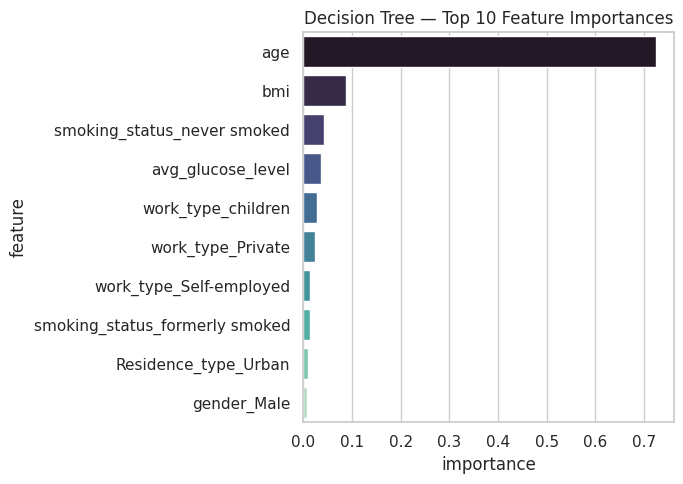

In [ ]:
feat_names = num + list(pre.named_transformers_["cat"].get_feature_names_out(cat))
importances = fitted["Decision Tree"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(data=imp_df, x="importance", y="feature", hue="feature", legend=False, palette="mako")
plt.title("Decision Tree — Top 10 Feature Importances")
plt.tight_layout()
plt.show()